
En esta versión, generalizamos el caso para N robots, consiguiendo que varios converjan a la trayectoria. Aún no se ha implementado el control sobre los parámetros para que mantengan las distancias. Todo esto en $R^2$, por lo que $n = 2$ ($n \equiv dimensión$). En otro código trataremos el caso en $R^3$

Implementamos las bibliotecas pertinentes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Definimos los parámetros de la simulación, siendo $n = 2$ las dimensiones (no tocar, falta generalizarlo), $nrob$ el número de robots, $t\_ sim$ el tiempo integrado, y $posmin$ y $posmax$ delimitan los límites en los que se disponen inicialmente a los robots de forma aleatoria.

In [2]:
n = 2
nrob = 20
t_sim = (0,10)
posmin = -6
posmax = 6

A continuación definimos las funciones del algoritmo. $f(t)$ es la curva parametrizada a la que tienden los robtos y $df(t)$ es la tangente a la curva. $phi(x,y,t)$ es la distancia de la posición del robot al punto de la curva $f(t)$.

In [3]:

def f(t):
    fx = t*np.cos(t*2.4)/2
    fy = t*np.sin(t)/1.5
    
    return np.array([fx, fy])

def df(t,h=1e-5):
    Df = (f(t+h)-f(t-h))/(2*h)

    return np.array([Df[0], Df[1]])

def phi(x,y,t):
    phix = x - f(t)[0]
    phiy = y - f(t)[1]

    return np.array([phix,phiy])

Debemos resolver la ecuación diferencial numéricamente:  
  
$\quad\dot{\vec{x}} = \vec{v}(\vec{x})$  
  
Para ello, establecemos las condiciones iniciales, y los parámetros $kx$ y $ky$, que caracterizan la velocidad con la que convergen los robots a las trayectorias deseadas:

In [4]:
pos0 = np.random.uniform(low=posmin, high=posmax, size=(n, nrob))
rob0 = np.vstack((pos0,np.zeros(pos0.shape[1])))

kx = 0.2
ky = 0.2

Ahora definimos la función $\vec{v}(\vec{x})$

In [5]:
def vec(t,tray):
    x = tray[0]
    y = tray[1]
    w = tray[2]
    evol = np.array([(-1)**n*df(w)[0]-kx*phi(x,y,w)[0],
             (-1)**n*df(w)[1]-ky*phi(x,y,w)[1],
             (-1)**n + kx*phi(x,y,w)[0]*df(w)[0] + ky*phi(x,y,w)[1]*df(w)[1]])
    return evol
    

Resolvemos la ecuación, pintando las posiciones iniciales con cruces negras, las trayectorias con curvas transparentes, y la curva a la que tienden los robots de color rojo y a rayas.

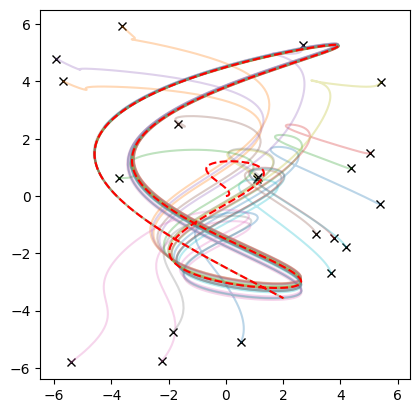

In [6]:
#Definir w_f es únicamente para dibujar la curva f(t)
w_f = []

for i in range(nrob):  
    Trayectoria = 0
    Trayectoria = solve_ivp(vec,t_sim,rob0[:,i],method='RK45',rtol=1e-8,atol=1e-10)

    #Esto es para obtener el parametro w hasta el que ha llegado cada robot al final de la simulación
    w_f.append((Trayectoria.y[2])[-1])

    #Dibujamos posiciones iniciales con x, y las trayectorias
    plt.plot(rob0[0,i],rob0[1,i],marker='x',color='k')
    plt.plot(Trayectoria.y[0],Trayectoria.y[1],alpha = 0.3)

#Dibujamos la curva hasta la posición del robot que más a trazado la curva
t_dibujo = np.linspace(0,max(w_f),500)
dibujo = f(t_dibujo)

plt.xlim(posmin,posmax)
plt.ylim(posmin,posmax)
plt.axis('square')
plt.plot(dibujo[0],dibujo[1],'r--')

plt.show()